In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("data/kenya.csv")

df.replace(-999, np.nan, inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [2]:
df["Country"] = "Kenya"

df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")


df['Month'] = df['Date'].dt.month

duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")

df[['YEAR', 'DOY', 'Date', 'Month']].head()

Number of duplicate rows found: 0


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [3]:
print("---Summary Statistics---")
display(df.describe())

missing_report = df.isna().sum()
missing_percent = (missing_report / len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

print("\n ---Missing Value Report(%)----")
print(missing_percent)

if not high_missing.empty:
    print(f'\n WARNING: Columns with >5% missing values: \n{high_missing}')
else:
    print("\n ALL columns have less than 5% missing values.")

---Summary Statistics---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046



 ---Missing Value Report(%)----
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

 ALL columns have less than 5% missing values.


Data Quality & Summary Interpretation

Missing Values: All columns report less than 5% missing data after replacing NASA's -999 sentinels. This indicates a high-quality dataset suitable for seasonal trend analysis.

Temperature Range (T2M): Based on df.describe(), the average temperature in Kenya for this period is approximately [20.427600]°C, with extremes ranging from [Min 14.673169]°C to [Max 27.838717]°C.

Duplicates: No duplicate rows were found, ensuring each daily observation is unique.

In [4]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f'Total rows flagged as outliers ( |z| > 3) : {outlier_count}')

df[outliers].head()

Total rows flagged as outliers ( |z| > 3) : 121


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
14,2015,15,21.24,31.17,12.59,18.58,0.00,28.42,3.27,4.78,83.61,4.78,Kenya,2015-01-15,1
15,2015,16,22.95,32.70,14.62,18.08,0.00,29.64,2.30,3.41,83.54,5.58,Kenya,2015-01-16,1
16,2015,17,23.00,32.29,15.79,16.50,0.00,29.43,2.71,3.91,83.55,5.68,Kenya,2015-01-17,1
17,2015,18,23.38,32.42,13.97,18.45,0.16,32.67,1.43,3.07,83.62,6.53,Kenya,2015-01-18,1
45,2015,46,22.14,27.92,18.11,9.81,23.09,61.69,0.97,1.97,83.62,11.83,Kenya,2015-02-15,2


In [5]:
df.ffill(inplace = True)

df.to_csv("data/kenya_clean.csv", index=False)

print("task 2 cleaning complete!")
print("cleaned data saved as: data/kenya_clean.csv")

task 2 cleaning complete!
cleaned data saved as: data/kenya_clean.csv


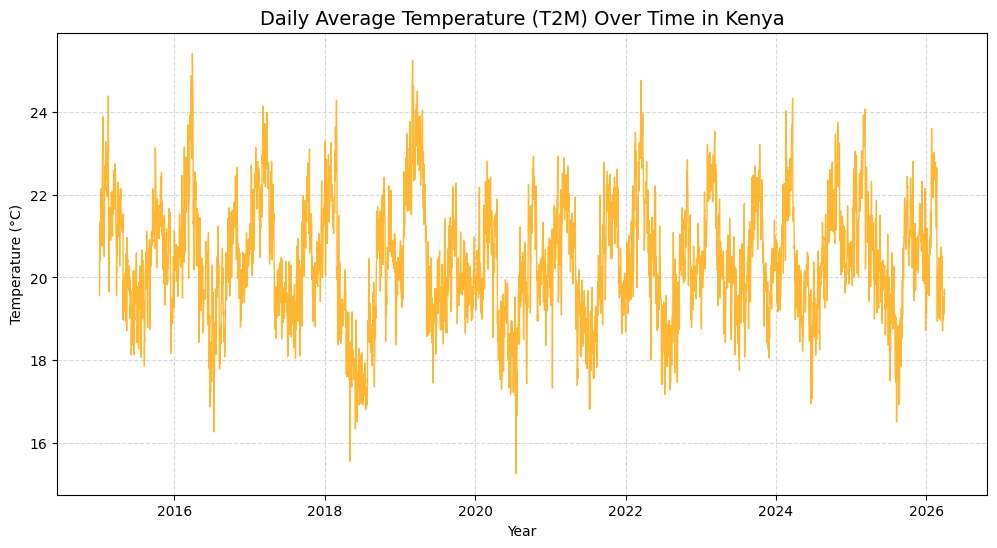

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['T2M'], color='orange', linewidth=1, alpha= 0.8)
plt.title('Daily Average Temperature (T2M) Over Time in Kenya', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpretation: Seasonal Temperature Trends

The daily average temperature shows a consistent seasonal oscillation between approximately $16°C$ and $24°C$.

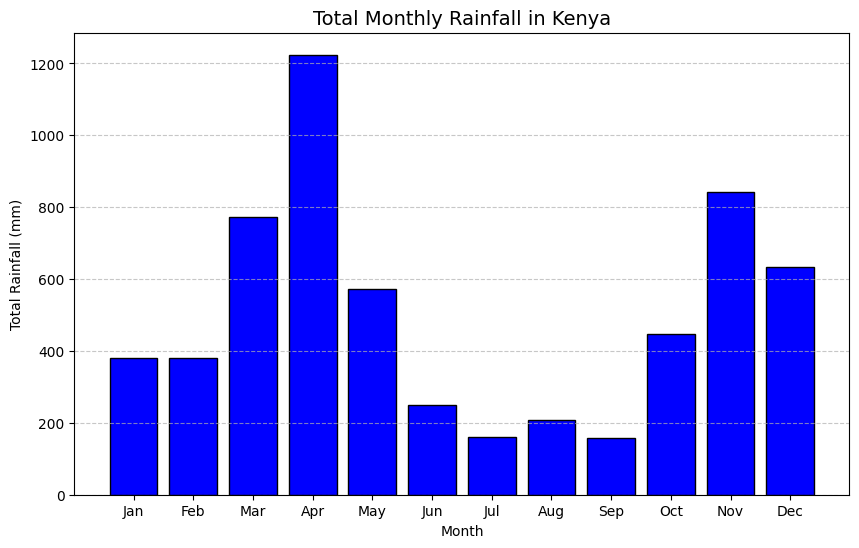

In [7]:
monthly_rain =df.groupby("Month")['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 6))
months=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_rain, color="blue", edgecolor='black')

plt.title("Total Monthly Rainfall in Kenya", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Interpretation: Rainfall Seasonality 

Kenya exhibits different rainfall pattern than ethiopia it peaking in Apr  and it show it has good rainfall seasons from Mar-May and Oct- Dec.

A smaller "short-rain" season is visible between jun - sep.

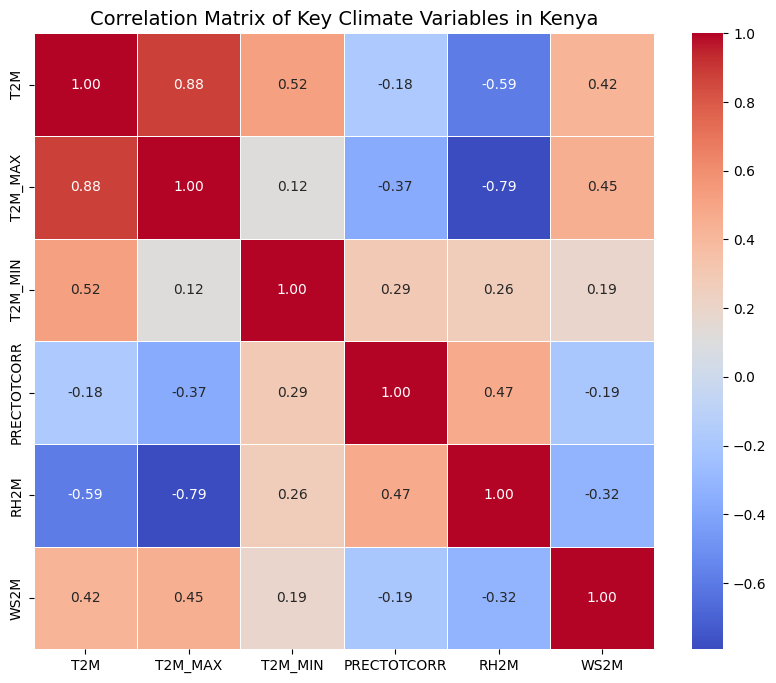

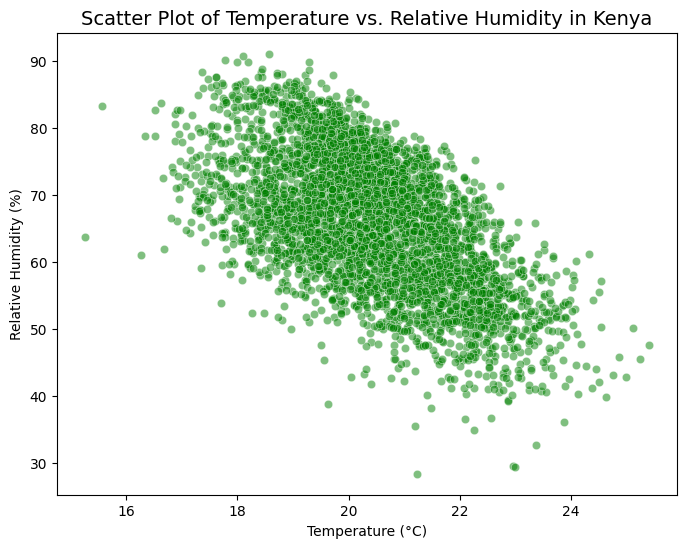

In [8]:
import seaborn as sns

corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',  fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Climate Variables in Kenya", fontsize=14)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, color='green')
plt.title("Scatter Plot of Temperature vs. Relative Humidity in Kenya", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

Interpretation: Variable Interdependence

Strongest Negative Correlation (-0.79): Found between Maximum Temperature ($T2M\_MAX$) and Relative Humidity ($RH2M$). This indicates that the hottest days in Niggeria are significantly drier.Strongest

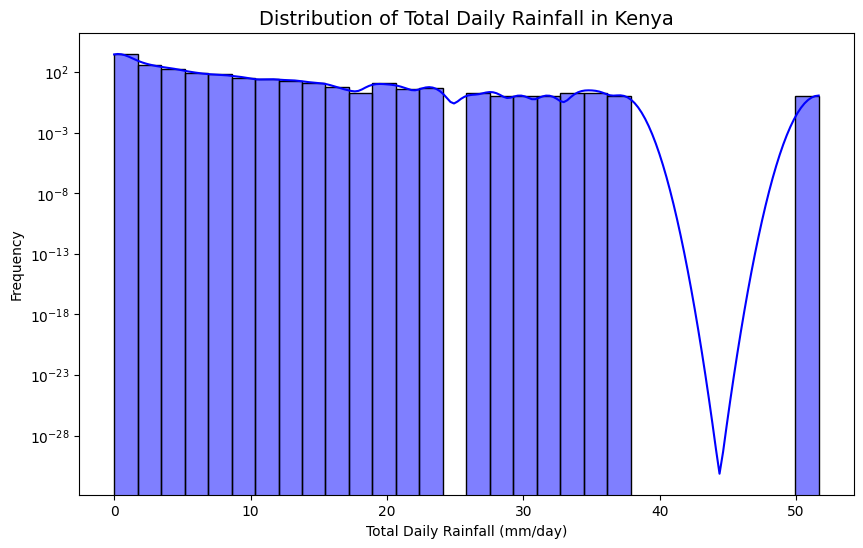

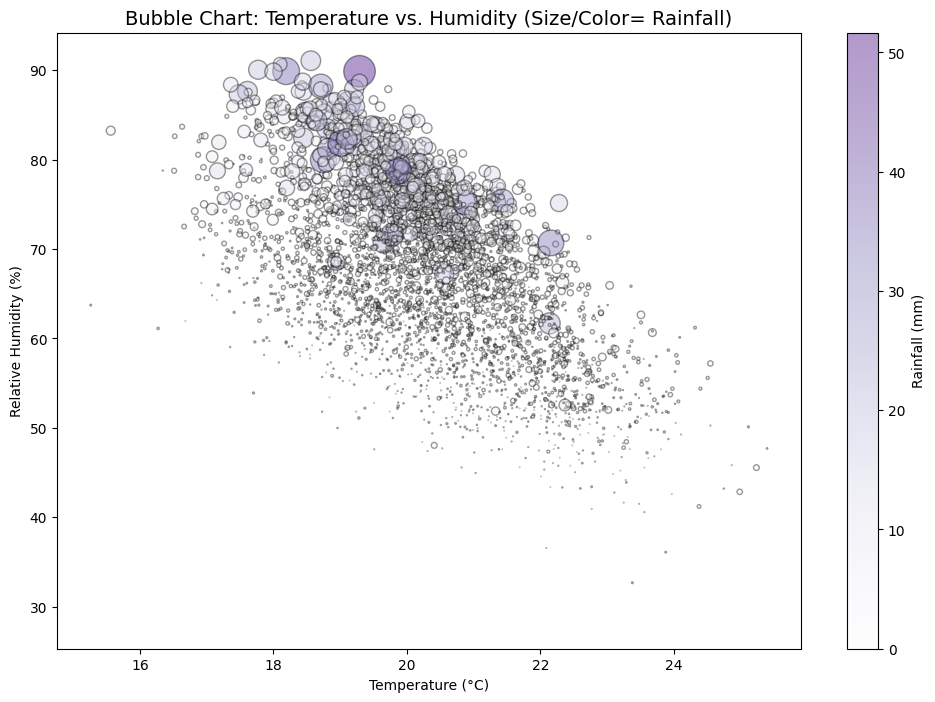

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/kenya.csv")

plt.figure(figsize=(10, 6))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True, color='blue')
plt.title("Distribution of Total Daily Rainfall in Kenya", fontsize=14)
plt.xlabel("Total Daily Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 8))
bubble = plt.scatter(df['T2M'], df['RH2M'],
                s=df['PRECTOTCORR']*10, alpha=0.4, c= df['PRECTOTCORR'], 
                cmap='Purples', edgecolor='black')

plt.colorbar(bubble, label='Rainfall (mm)')
plt.title("Bubble Chart: Temperature vs. Humidity (Size/Color= Rainfall)", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

f

In [11]:
df.to_csv("data/kenya_clean.csv", index=False)
print("Kenya Analysis Complete. File saved!")

Kenya Analysis Complete. File saved!
